In [22]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

from jiflr import ROOT
from jiflr.data import select_sensors, merge_sensor_datasets
from jiflr.utils import lapse_rate_ufunc


In [23]:
ds = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds = select_sensors(ds, height="2m", shielding="shielded")

ds_intensive = xr.open_dataset(
    ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc"
)
ds_intensive = select_sensors(ds_intensive, height="2m", shielding="shielded")

ds = merge_sensor_datasets(ds, ds_intensive)
da = ds.temp_c

In [24]:
print(ds_intensive.sensor_type.values)

['hobo pendant' 'hobo pendant' 'hobo pendant' 'hobo pendant'
 'hobo pendant']


In [25]:
C10_SITES = [
    "G04",
    "G03",
    "A02",
    "G02",
    "G01",
]
C18_SITES = ["F03", "Windward1", "F05"]

In [26]:
def subset_transect(da, sites):
    da_transect = da.where(da.site_id.isin(sites), drop=True)
    return da_transect.dropna(dim="datetime", how="any")


C10_transect = subset_transect(da, C10_SITES)
C18_transect = subset_transect(da, C18_SITES)

In [27]:
MARITIME_SITES = ["A04", "A05", "Windward2", "A06", "Windward1", "A07", "Divide"]

ds_maritime_raw = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_maritime_raw = select_sensors(ds_maritime_raw, height="2m", shielding="shielded")
ds_int_raw = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_intensive.nc")
ds_int_raw = select_sensors(ds_int_raw, height="2m", shielding="shielded")
ds_maritime_raw = merge_sensor_datasets(ds_maritime_raw, ds_int_raw)

da_maritime = ds_maritime_raw.temp_c.where(
    ds_maritime_raw.temp_c.site_id.isin(MARITIME_SITES), drop=True
)
da_maritime_1h = da_maritime.resample(datetime="1h").mean()
da_maritime_1h = da_maritime_1h.dropna(dim="datetime", how="any")

site_mask = da_maritime_1h.site_id.isin(MARITIME_SITES).values
slopes, _ = xr.apply_ufunc(
    lapse_rate_ufunc,
    da_maritime_1h,
    da_maritime_1h.elevation,
    site_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",
)
maritime_lapse_rate = pd.Series(
    -slopes,
    index=pd.DatetimeIndex(da_maritime_1h.datetime.values),
)

# Resample transects to hourly for use with the lapse rate
C10_transect_1h = C10_transect.resample(datetime="1h").mean()
C18_transect_1h = C18_transect.resample(datetime="1h").mean()

print(f"Maritime mean LR: {maritime_lapse_rate.mean()*1000:.2f} deg C/km")
print(f"C10 hourly timesteps: {C10_transect_1h.sizes['datetime']}")
print(f"C18 hourly timesteps: {C18_transect_1h.sizes['datetime']}")


Maritime mean LR: 1.59 deg C/km
C10 hourly timesteps: 612
C18 hourly timesteps: 816


In [28]:
def plot_transect_boxplots(da_transect, sites, title, output_path, lapse_rate=None):
    present_sites = da_transect.site_id.values.tolist()
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)

    box_kw = dict(
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        medianprops=dict(color="black", lw=1.5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
    )

    def collect(mask=None):
        data_list, labels = [], []
        for site in sites:
            if site not in present_sites:
                continue
            vals = da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
            if mask is not None:
                vals = vals[mask]
            vals = vals[~np.isnan(vals)]
            data_list.append(vals)
            labels.append(site)
        return data_list, labels

    if lapse_rate is not None:
        lr_aligned = lapse_rate.reindex(datetimes, method="nearest", tolerance=pd.Timedelta("30min"))
        conditions = [
            ("Normal (LR > 0)", lr_aligned.values > 0),
            ("Inverted (LR < 0)", lr_aligned.values < 0),
        ]
        _, labels = collect()
        fig, axes = plt.subplots(
            1, 2,
            figsize=(len(labels) * 1.2 + 2, 4),
            dpi=150,
            layout="constrained",
            sharey=True,
        )
        for ax, (cond_label, mask) in zip(axes, conditions):
            data_list, labels = collect(mask)
            ax.boxplot(data_list, labels=labels, **box_kw)
            ax.set_xlabel("Site")
            ax.set_ylabel("Temperature (°C)")
            ax.set_title(f"{cond_label}  (n={int(mask.sum())} timesteps)")
        fig.suptitle(title)
    else:
        data_list, labels = collect()
        fig, ax = plt.subplots(figsize=(len(labels) * 1.2 + 1, 4), dpi=150)
        ax.boxplot(data_list, labels=labels, **box_kw)
        ax.set_xlabel("Site")
        ax.set_ylabel("Temperature (°C)")
        ax.set_title(title)
        fig.tight_layout()

    fig.savefig(output_path)
    plt.show()
    return fig

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_77772/803649025.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=labels, **box_kw)
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_77772/803649025.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=labels, **box_kw)


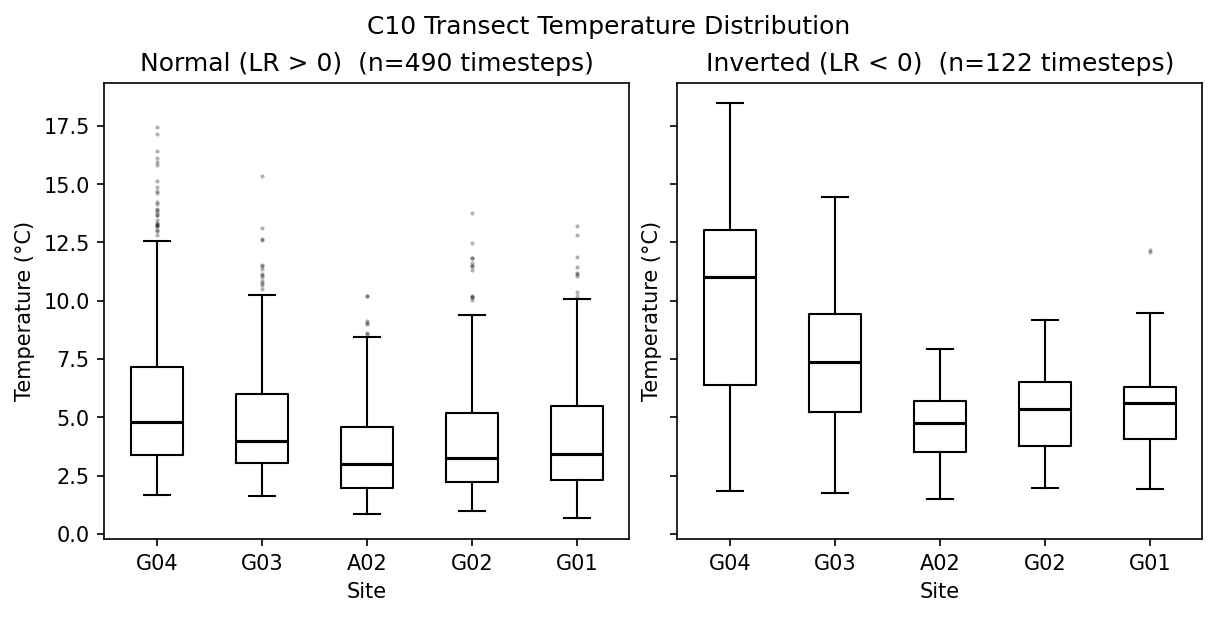

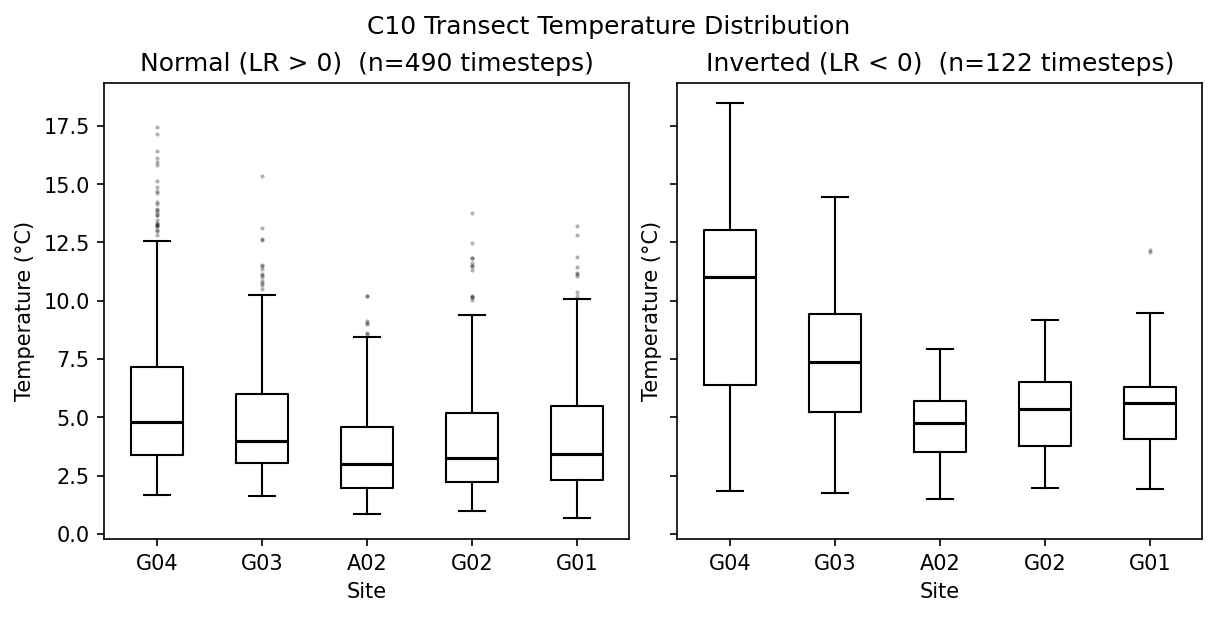

In [29]:
output_dir = ROOT / "notebooks/transect_boxplots/output"

plot_transect_boxplots(
    C10_transect_1h,
    C10_SITES,
    title="C10 Transect Temperature Distribution",
    output_path=output_dir / "C10_transect_boxplots.png",
    lapse_rate=maritime_lapse_rate,
)

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_77772/803649025.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=labels, **box_kw)
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_77772/803649025.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=labels, **box_kw)


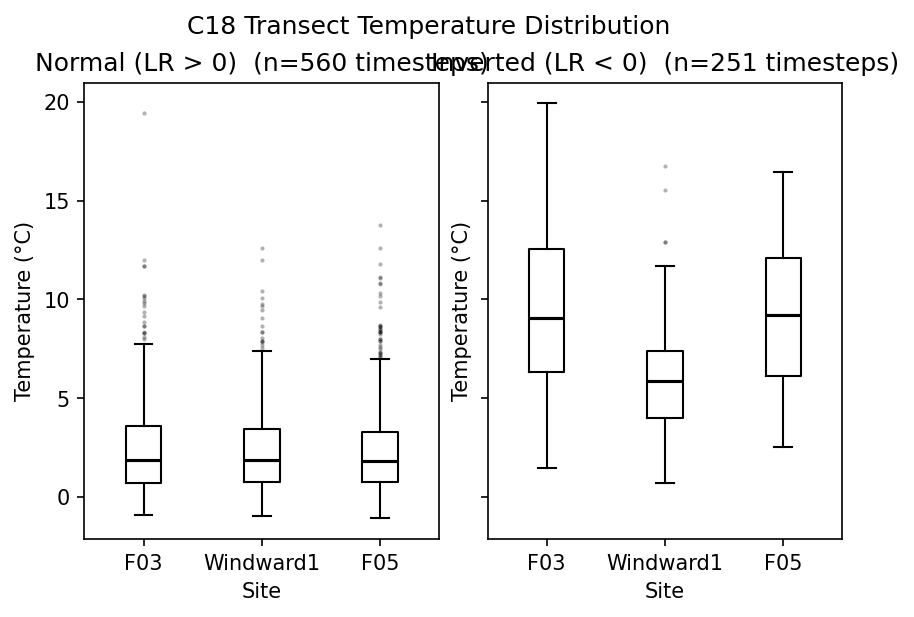

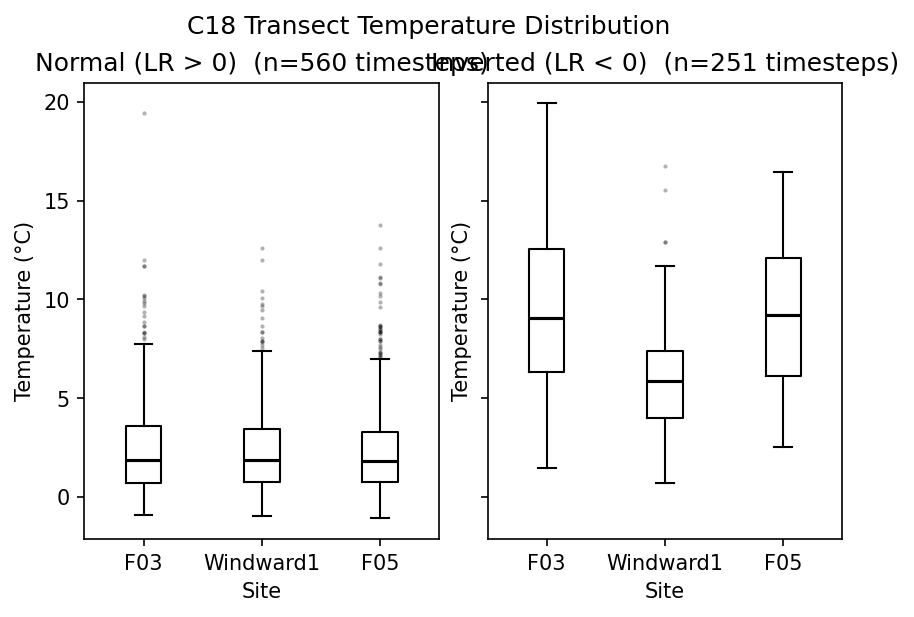

In [30]:
plot_transect_boxplots(
    C18_transect_1h,
    C18_SITES,
    title="C18 Transect Temperature Distribution",
    output_path=output_dir / "C18_transect_boxplots.png",
    lapse_rate=maritime_lapse_rate,
)

In [31]:
C10_transect_15 = C10_transect.resample(datetime="15min").mean()
C18_transect_15 = C18_transect.resample(datetime="15min").mean()

In [53]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import pandas as pd


def plot_hourly_mean_transect(
    da_transect, sites, title, output_path, lapse_rate=None,
    index_site=None, exclude_hours=None
):
    """Plot mean temperature across a transect for each hour of day.

    If lapse_rate is provided, produces a 2-panel figure split by LR sign
    (left: LR > 0 normal, right: LR < 0 inverted). Otherwise single panel.
    A single rainbow colorbar is shared on the right.
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
    x_pos = np.arange(len(present_sites))

    site_elevations = {}
    for site in present_sites:
        match = da_transect.where(da_transect.site_id == site, drop=True)
        if "elevation" in match.coords and match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    temps = np.stack(
        [da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
         for site in present_sites],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    date_start = datetimes.min().strftime("%Y-%m-%d")
    date_end = datetimes.max().strftime("%Y-%m-%d")

    xticklabels = [
        f"{s}\n{site_elevations[s]:.0f} m" if s in site_elevations else s
        for s in present_sites
    ]

    if index_site is not None:
        assert index_site in present_sites, f"index_site '{index_site}' not found in transect"
        ylabel = f"Temperature relative to {index_site} (°C)"
    else:
        ylabel = "Mean Temperature (°C)"

    # Shared colormap over all 24 hours
    hours = np.arange(24)
    n_hours = len(hours)
    colors = plt.get_cmap("rainbow", n_hours)(np.arange(n_hours))
    cmap = mcolors.ListedColormap(colors)
    bounds = np.arange(-0.5, n_hours + 0.5, 1)
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_hours)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    if lapse_rate is not None:
        lr_aligned = lapse_rate.reindex(df.index, method="nearest",
                                        tolerance=pd.Timedelta("30min"))
        conditions = [
            ("Normal (LR > 0)", lr_aligned > 0),
            ("Inverted (LR < 0)", lr_aligned < 0),
        ]
        n_panels = 2
    else:
        conditions = [("All periods", pd.Series(True, index=df.index))]
        n_panels = 1

    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(6*n_panels, 6),
        dpi=200,
        layout="constrained",
        sharey=True,
    )
    if n_panels == 1:
        axes = [axes]

    for ax, (cond_label, mask) in zip(axes, conditions):
        df_filt = df[mask.values]
        n_pts = int(mask.sum())

        hourly_mean = df_filt.groupby(df_filt.index.hour).mean()
        if exclude_hours:
            hourly_mean = hourly_mean.drop(
                index=[h for h in exclude_hours if h in hourly_mean.index]
            )
        if index_site is not None:
            hourly_mean = hourly_mean.subtract(hourly_mean[index_site], axis=0)

        for hour in hourly_mean.index:
            ax.plot(x_pos, hourly_mean.loc[hour].values,
                    marker="o", color=colors[hour], lw=1.5, alpha=0.85)

        ax.set_xlim(-0.5, len(present_sites) - 0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels)
        ax.set_xlabel("Site")
        
        ax.set_title(f"{cond_label}  (n={n_pts} timesteps)")

        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
        ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
        ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.4)

        if index_site is not None:
            ax.axvline(present_sites.index(index_site), color="black",
                       linestyle="--", linewidth=1, alpha=0.5)
    axes[0].set_ylabel(ylabel)
    cbar = fig.colorbar(sm, ax=axes[-1], ticks=np.arange(0, n_hours, 2),
                        boundaries=bounds, spacing="uniform", pad=0.02)
    cbar.set_label("Hour of Day")
    cbar.set_ticklabels([str(h) for h in range(0, n_hours, 2)])

    title_str = f"{title}\n{date_start} to {date_end}"
    if index_site is not None:
        title_str += f"  |  Reference site: {index_site}"
    fig.suptitle(title_str)

    fig.savefig(output_path)
    return fig


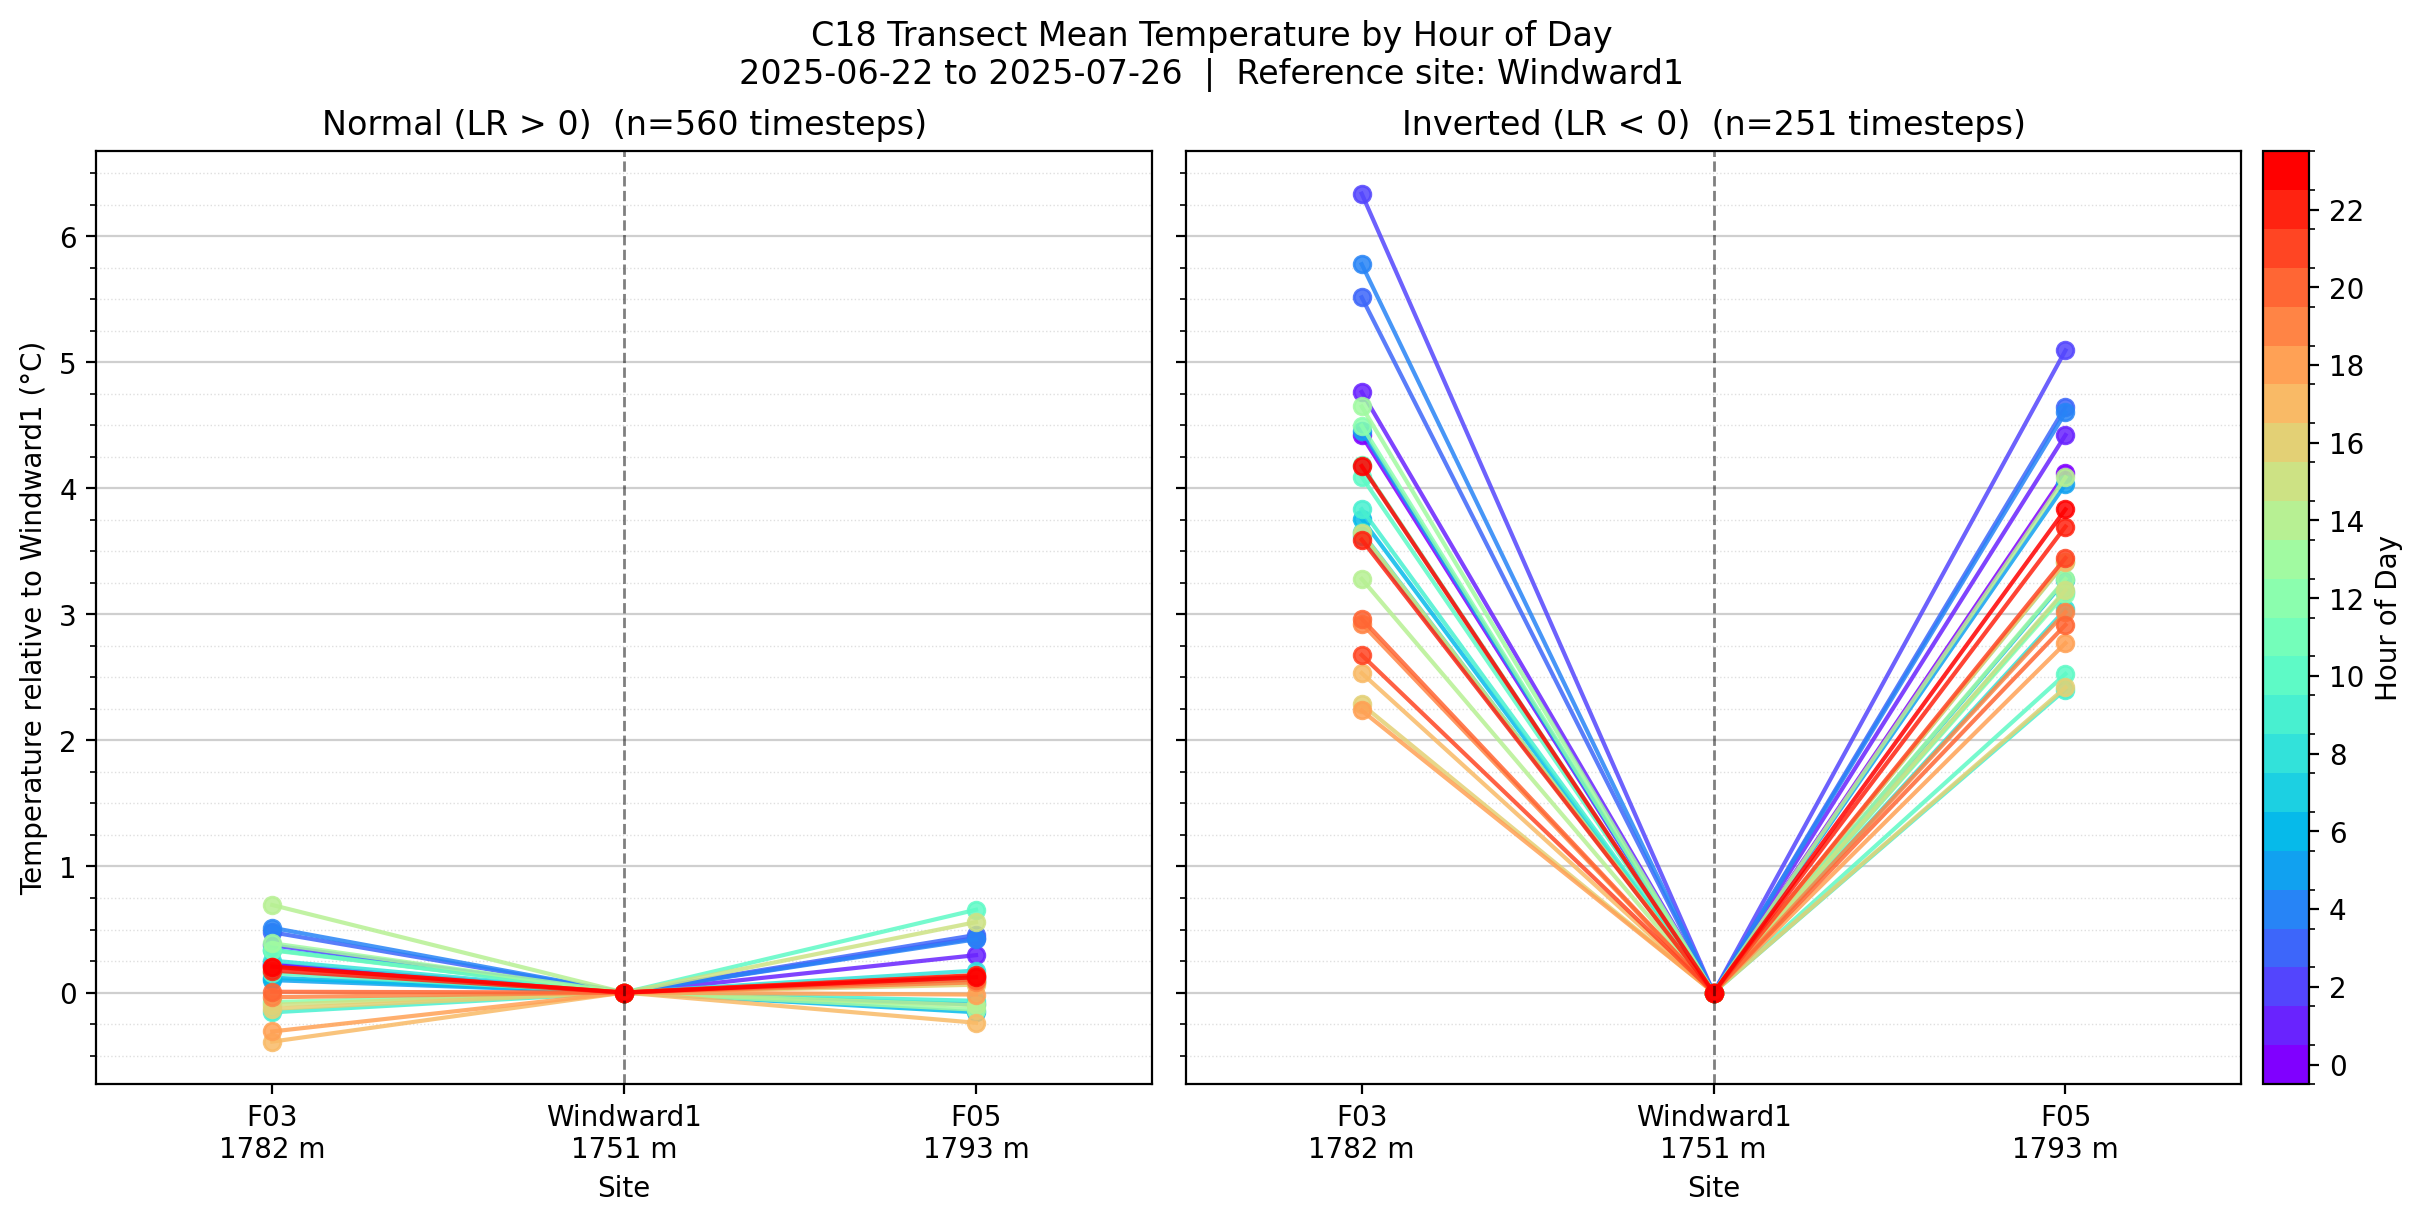

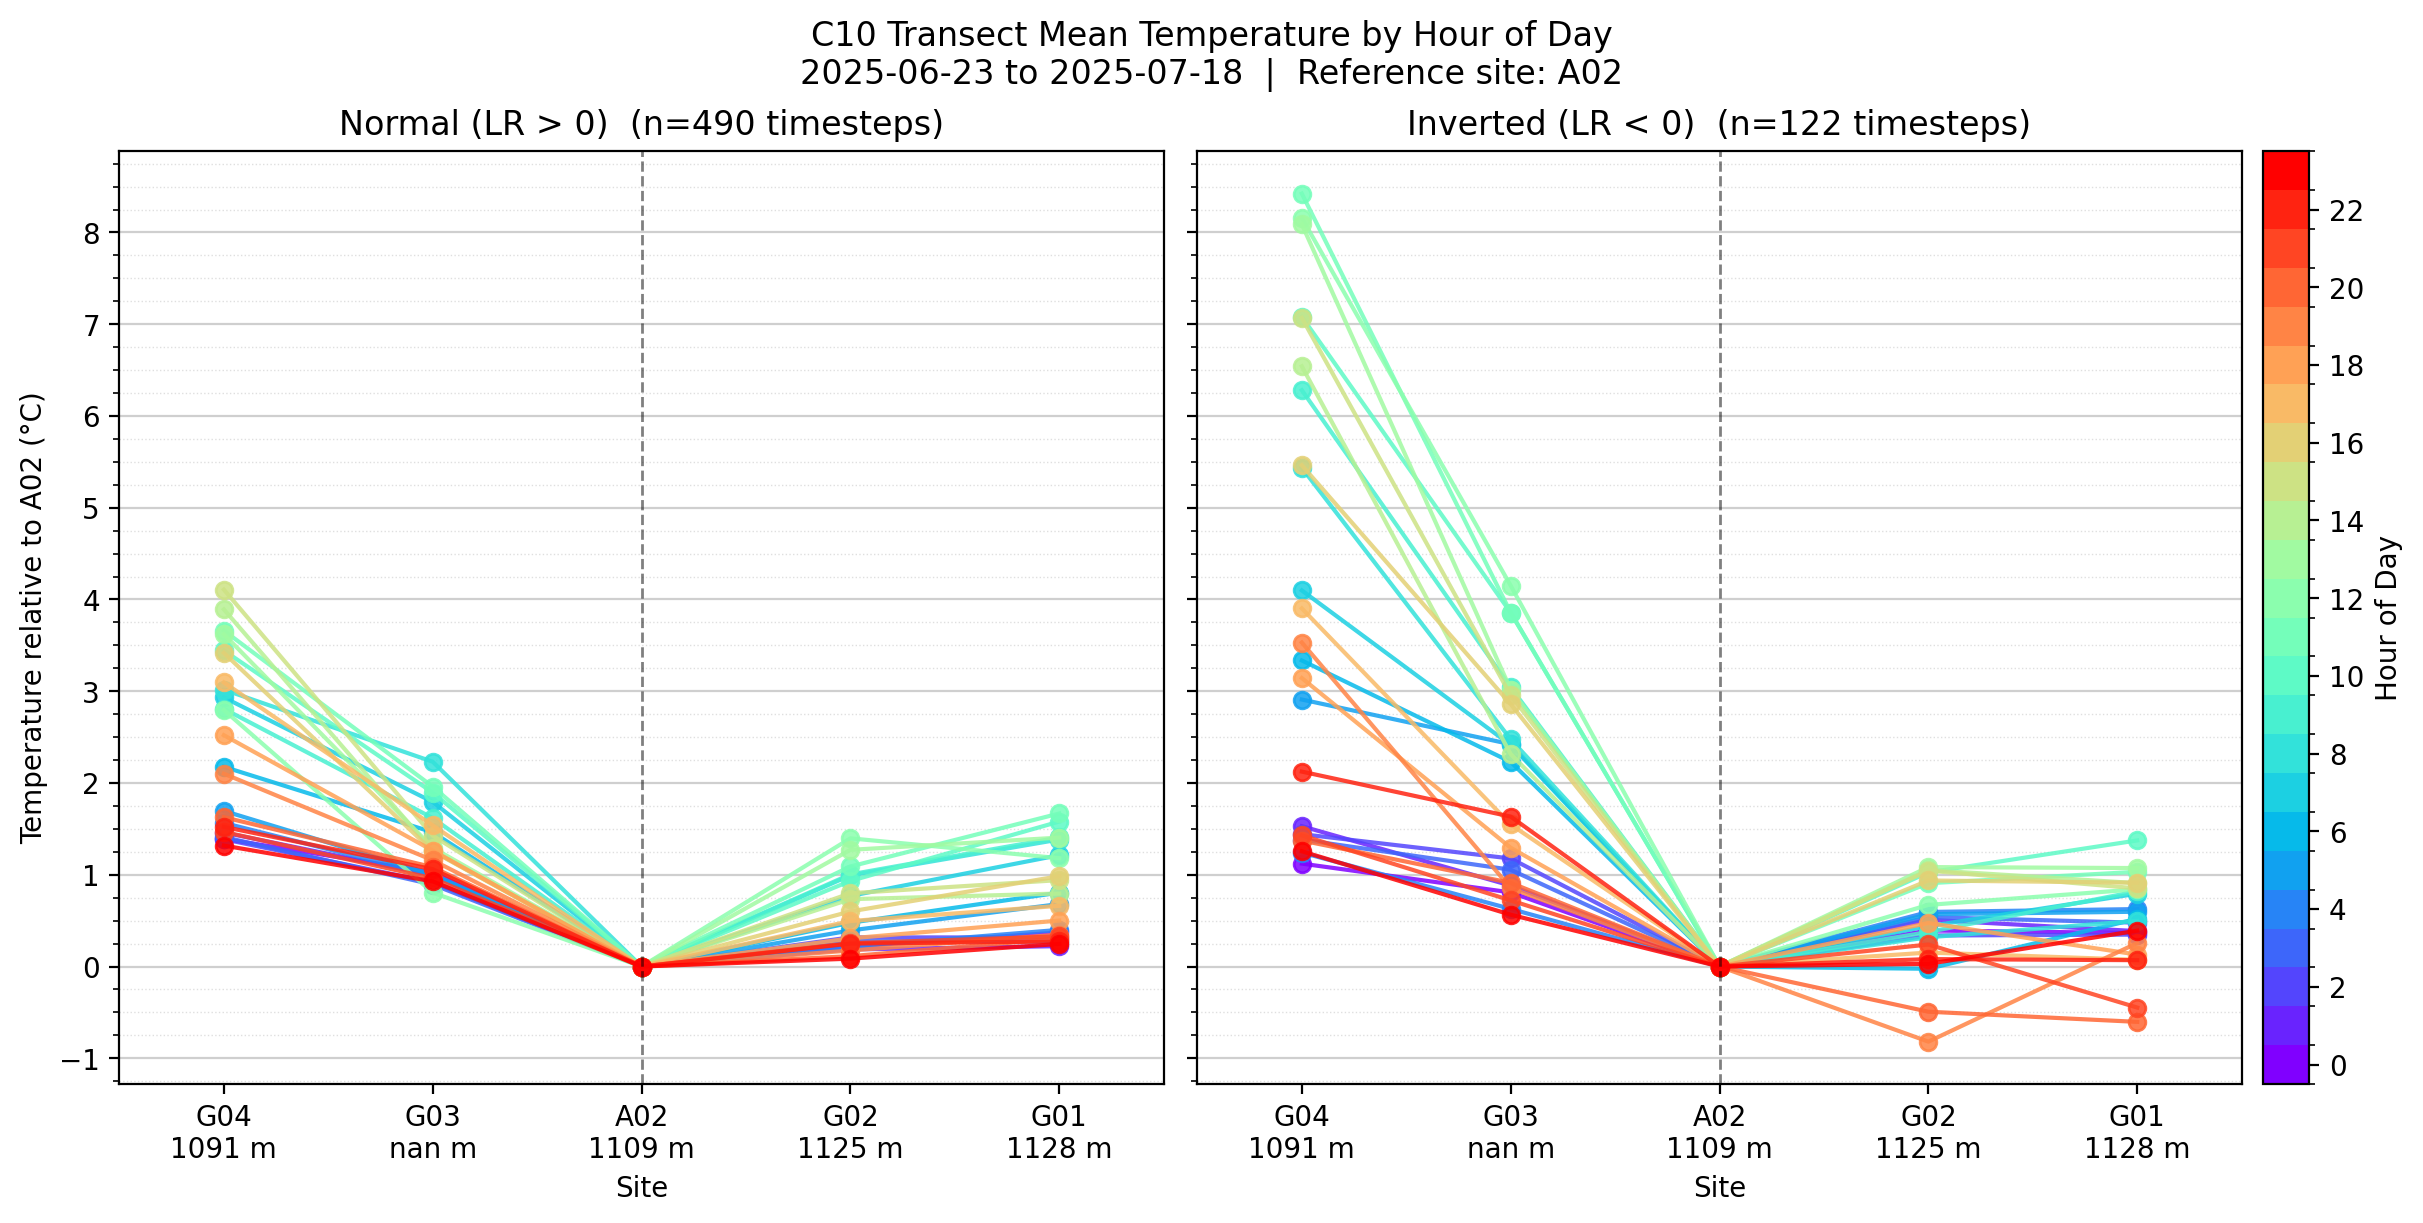

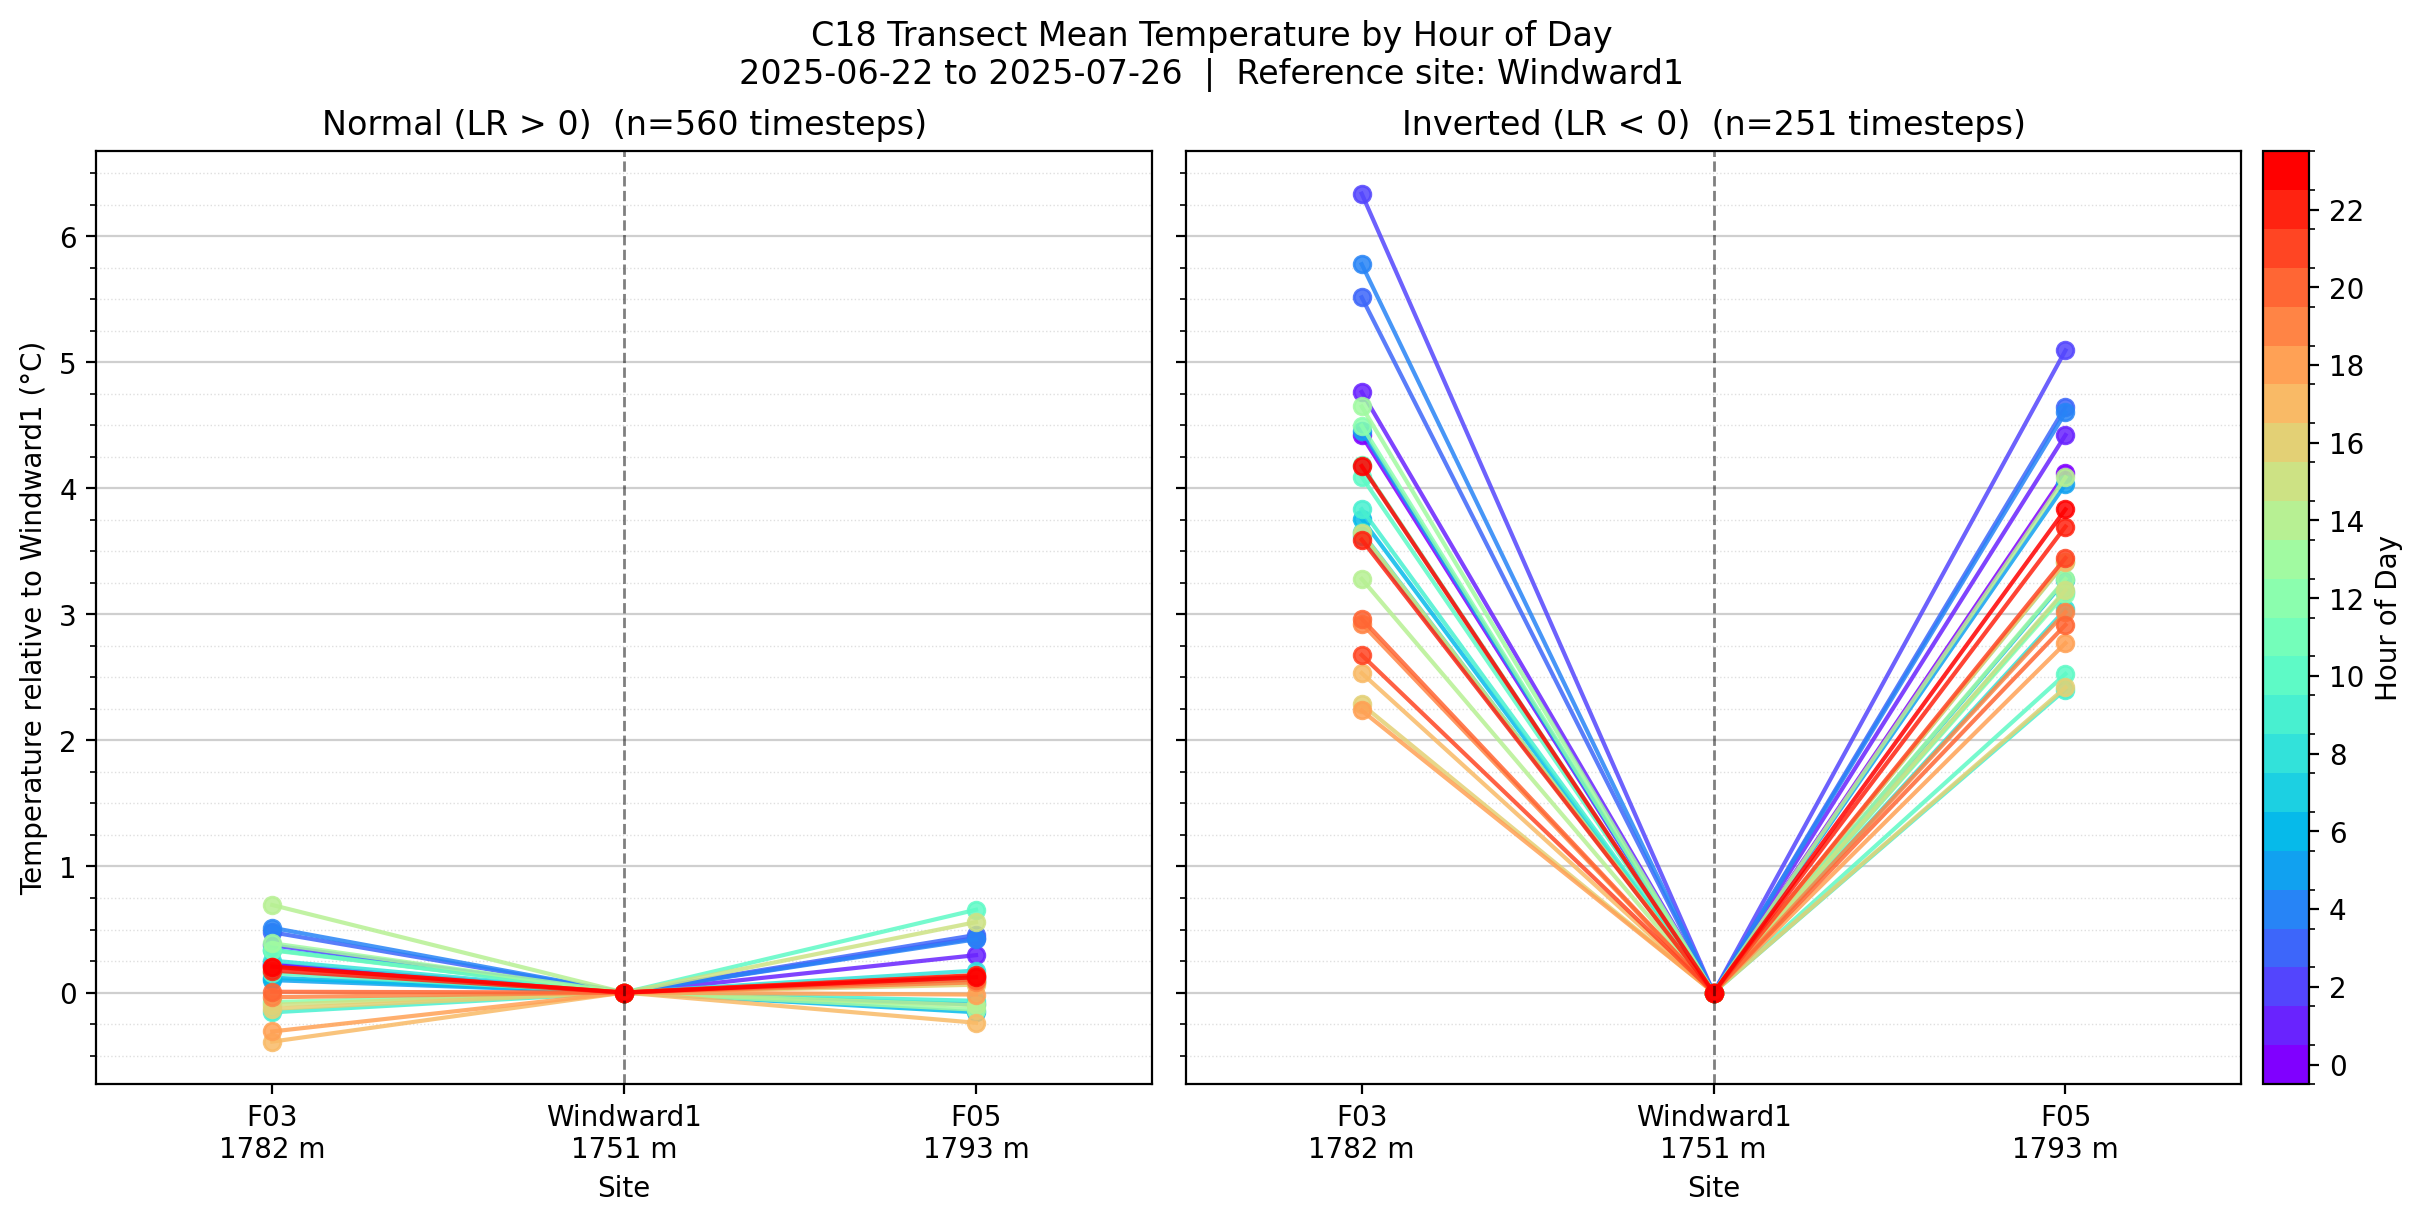

In [54]:
EXCLUDE_HOURS = []

plot_hourly_mean_transect(
    C10_transect_1h,
    C10_SITES,
    title="C10 Transect Mean Temperature by Hour of Day",
    output_path=output_dir / "C10_transect_hourly_mean.png",
    lapse_rate=maritime_lapse_rate,
    index_site="A02",
    exclude_hours=EXCLUDE_HOURS,
)

plot_hourly_mean_transect(
    C18_transect_1h,
    C18_SITES,
    title="C18 Transect Mean Temperature by Hour of Day",
    output_path=output_dir / "C18_transect_hourly_mean.png",
    lapse_rate=maritime_lapse_rate,
    index_site="Windward1",
    exclude_hours=EXCLUDE_HOURS,
)


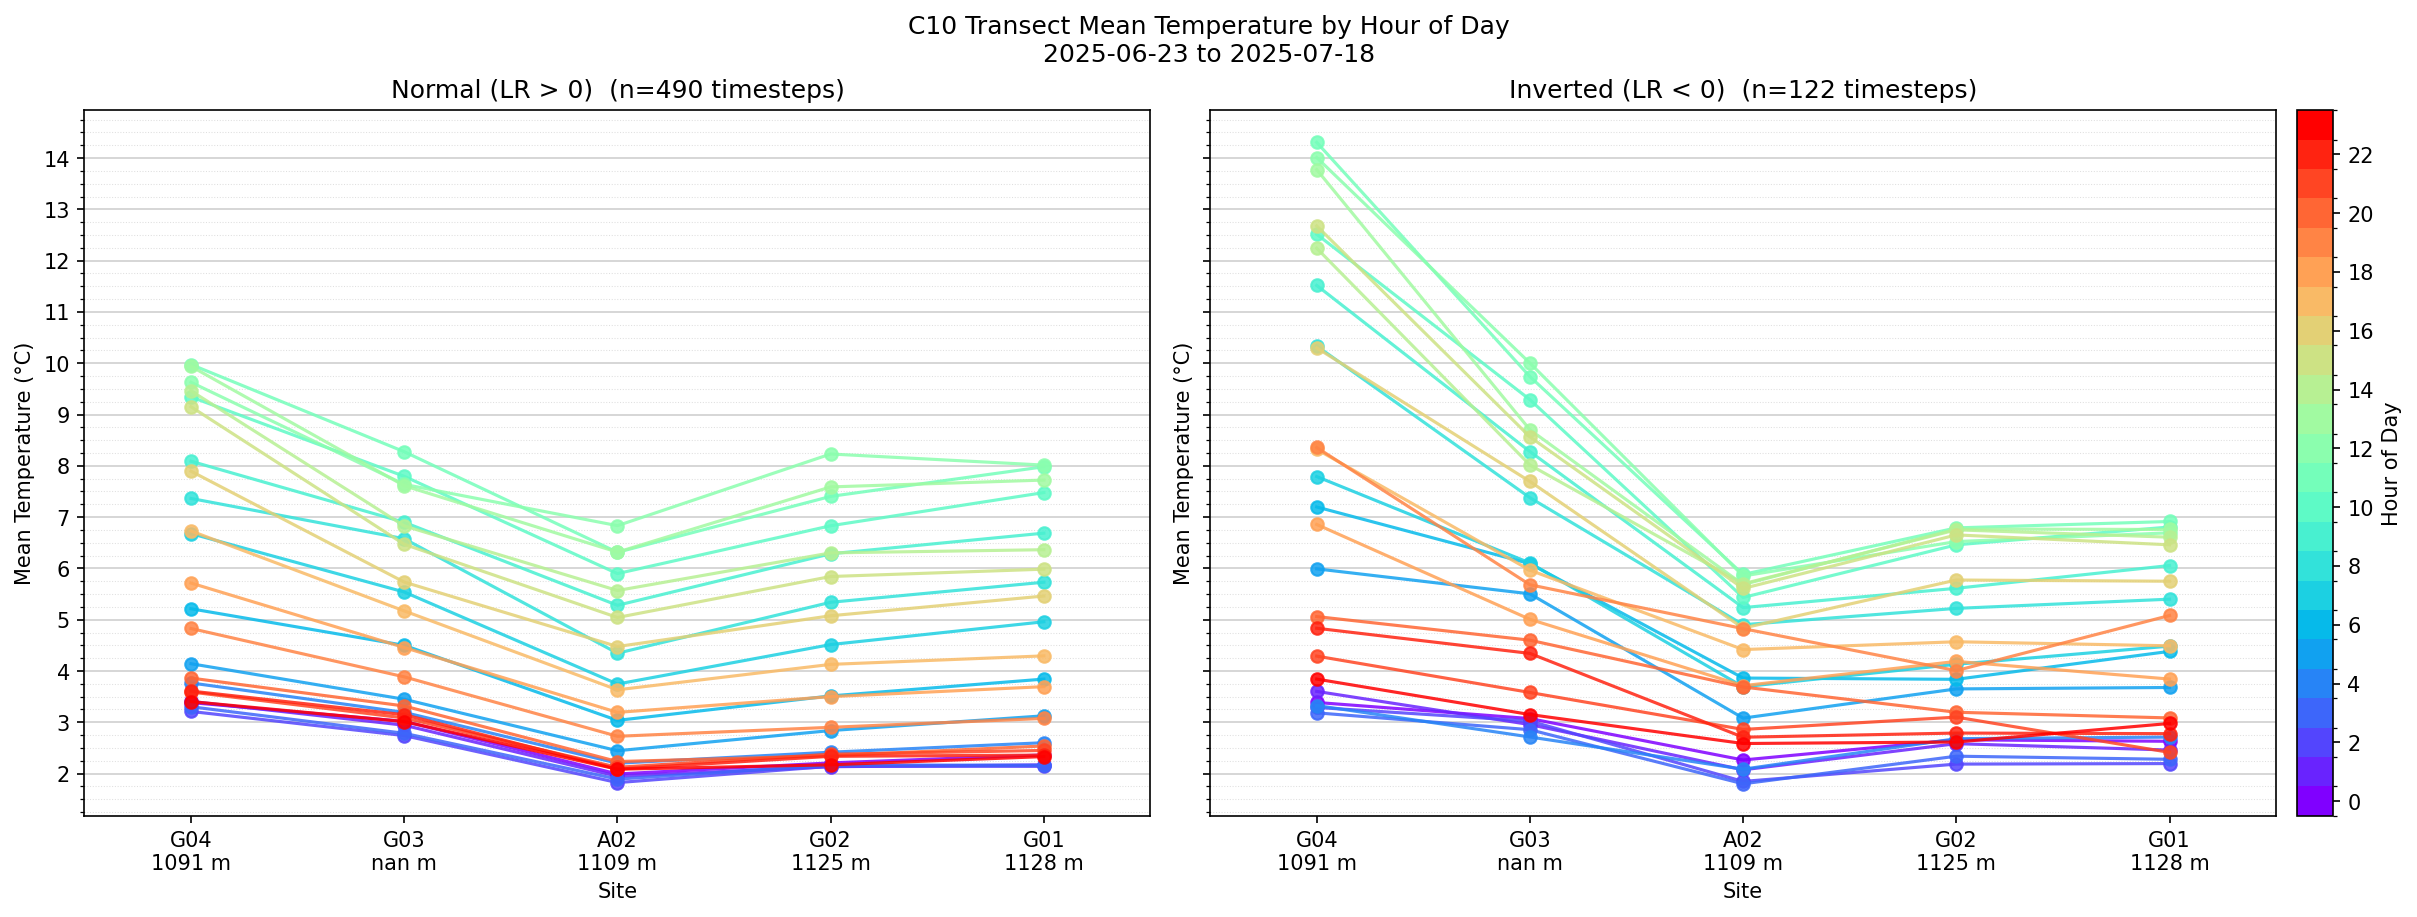

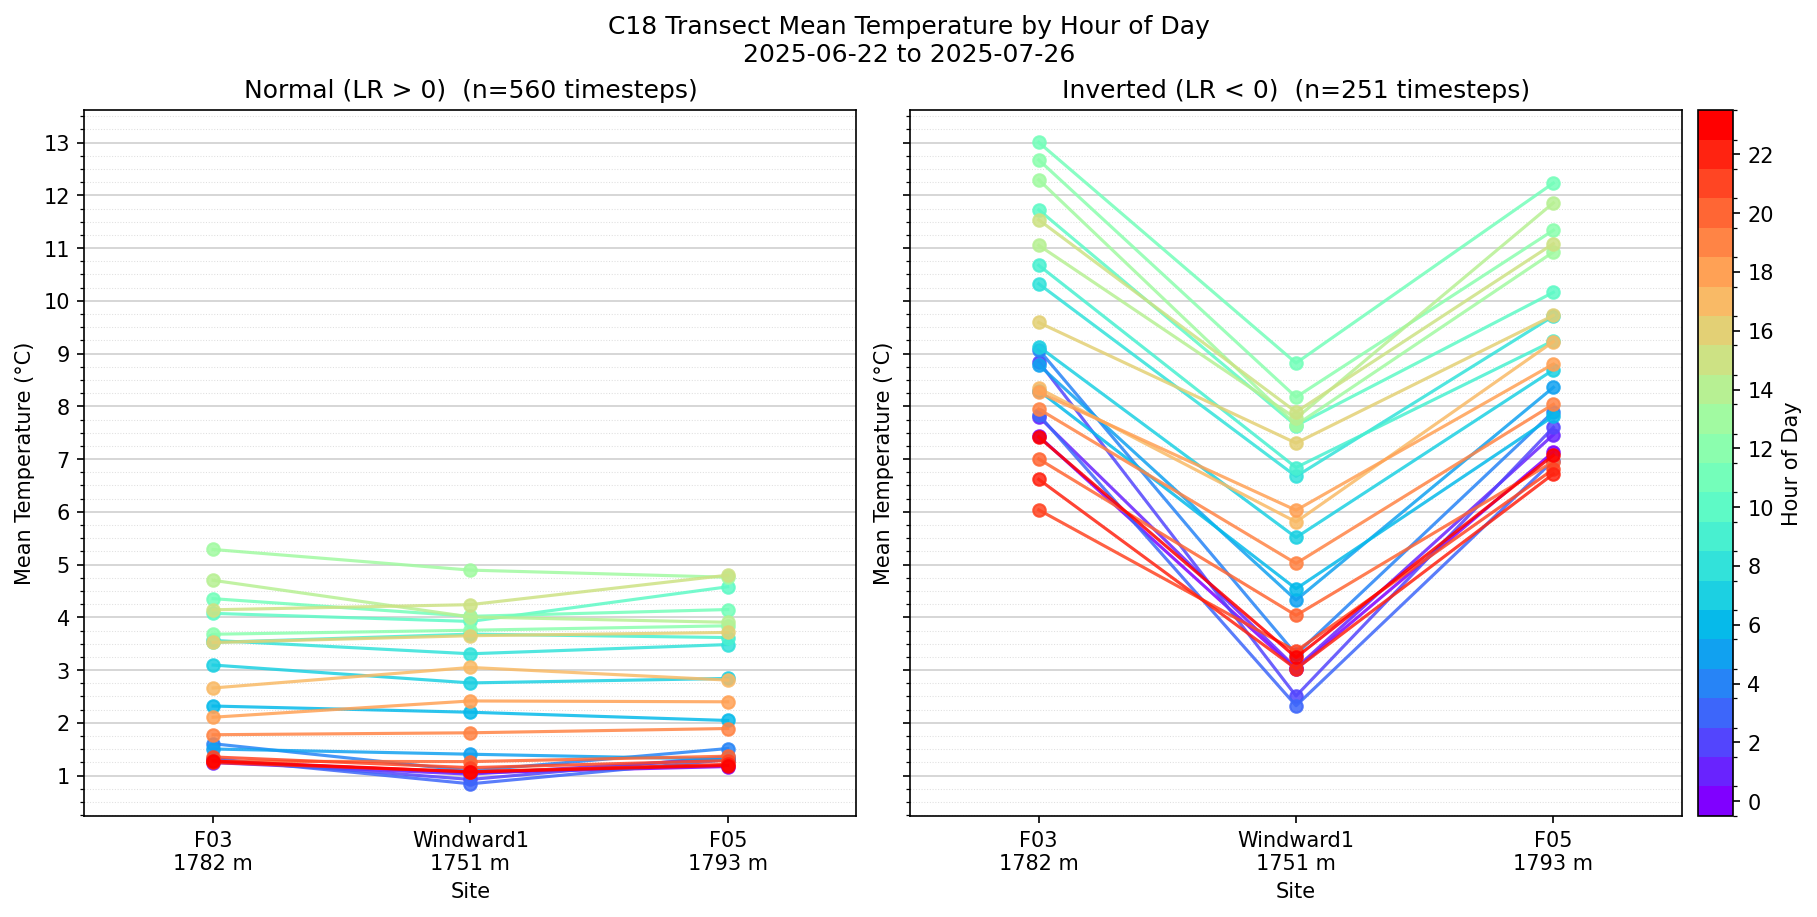

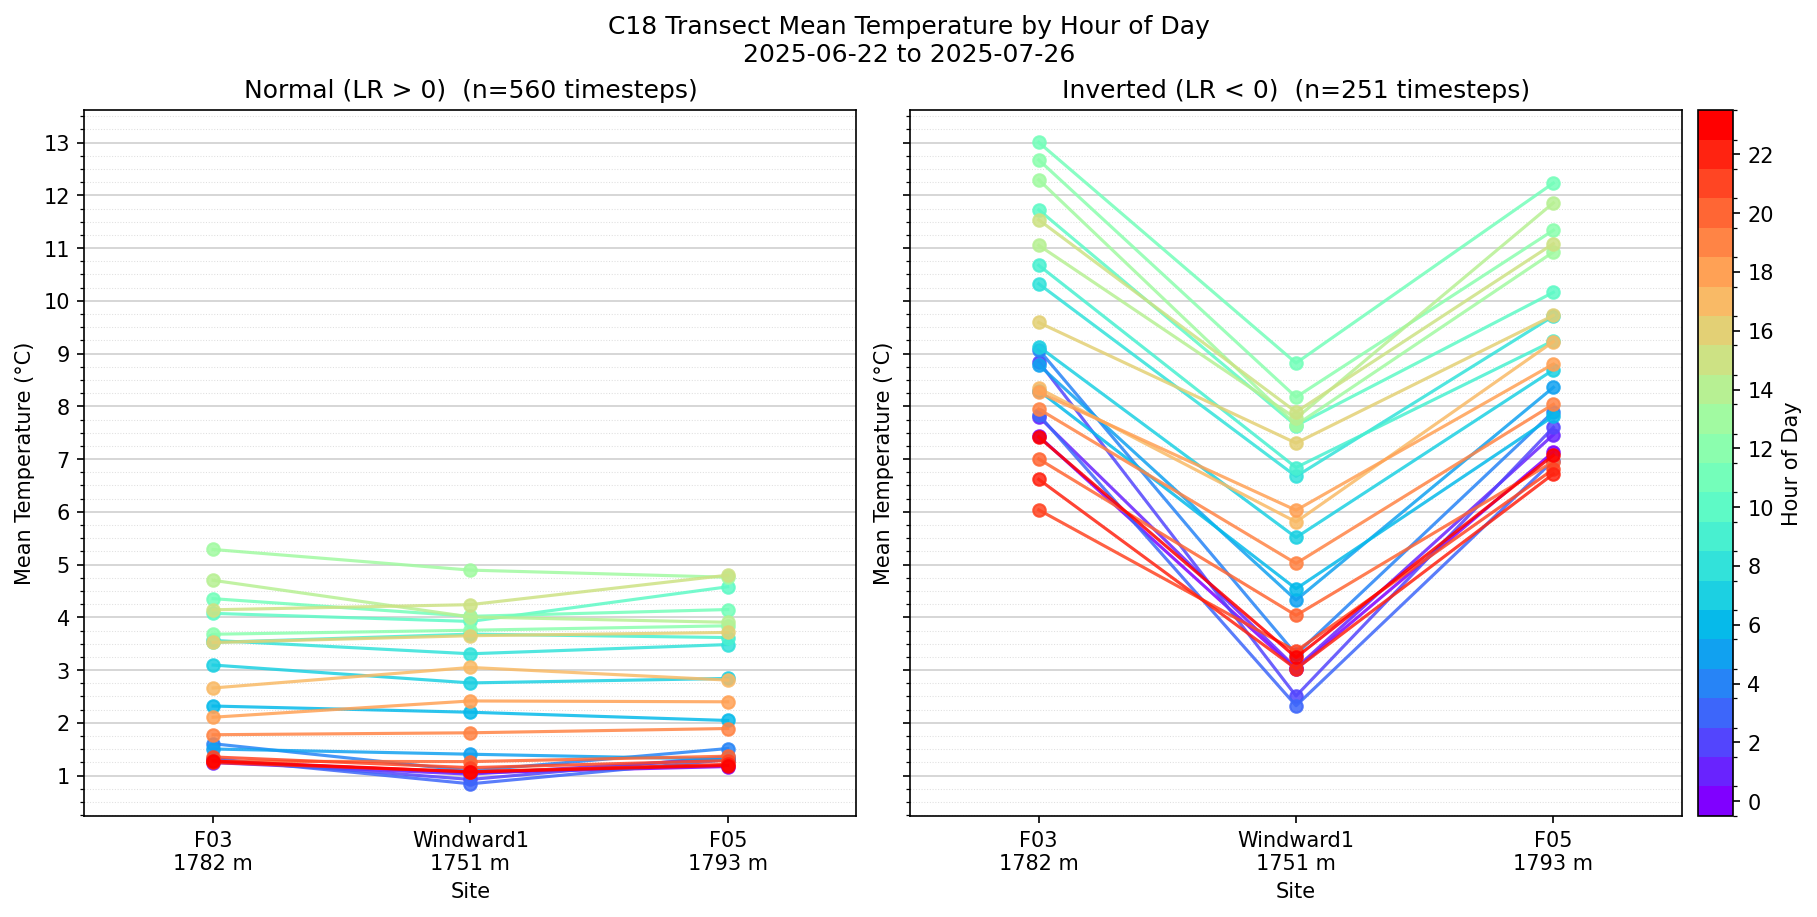

In [34]:
plot_hourly_mean_transect(
    C10_transect_1h,
    C10_SITES,
    title="C10 Transect Mean Temperature by Hour of Day",
    output_path=output_dir / "C10_transect_hourly_mean_abs.png",
    lapse_rate=maritime_lapse_rate,
)

plot_hourly_mean_transect(
    C18_transect_1h,
    C18_SITES,
    title="C18 Transect Mean Temperature by Hour of Day",
    output_path=output_dir / "C18_transect_hourly_mean_abs.png",
    lapse_rate=maritime_lapse_rate,
)


In [35]:
def plot_transect_at_hour(da_transect, sites, title, output_path, hour, lapse_rate=None):
    """Plot one line per day at a given hour of day as thin transparent lines,
    with the mean across days plotted on top.

    If lapse_rate is provided, produces a 2-column figure split by LR sign.
    Sub-hourly data is averaged within each day-hour bucket so that n equals
    the number of days and each line represents one day. Lines are colored by
    date using the plasma colormap.
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
    x_pos = np.arange(len(present_sites))

    site_elevations = {}
    for site in present_sites:
        match = da_transect.where(da_transect.site_id == site, drop=True)
        if "elevation" in match.coords and match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    temps = np.stack(
        [da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
         for site in present_sites],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    date_start = datetimes.min().strftime("%Y-%m-%d")
    date_end = datetimes.max().strftime("%Y-%m-%d")

    xticklabels = [
        f"{s}\n{site_elevations[s]:.0f} m" if s in site_elevations else s
        for s in present_sites
    ]

    def build_hour_df(df_subset):
        return (
            df_subset[df_subset.index.hour == hour]
            .groupby(df_subset[df_subset.index.hour == hour].index.date)
            .mean()
            .dropna(how="any")
        )

    def draw_panel(ax, hour_df, cond_label):
        n_days = len(hour_df)
        cmap = plt.get_cmap("plasma")
        norm = mcolors.Normalize(vmin=0, vmax=max(n_days - 1, 1))
        for i, (_, row) in enumerate(hour_df.iterrows()):
            ax.plot(x_pos, row.values, color=cmap(norm(i)), lw=1.5, alpha=0.5)
        mean_vals = hour_df.mean().values
        ax.plot(x_pos, mean_vals, color="black", lw=2, marker="o", zorder=5, label="Mean")
        ax.set_xlim(-0.5, len(present_sites) - 0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels)
        ax.set_xlabel("Site")
        ax.set_ylabel("Temperature (°C)")
        ax.set_title(f"{cond_label}  (n={n_days} days)")
        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
        ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
        ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
        ax.legend()
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_ticks([0, n_days - 1])
        cbar.set_ticklabels([
            hour_df.index[0].strftime("%m-%d"),
            hour_df.index[-1].strftime("%m-%d"),
        ])

    if lapse_rate is not None:
        lr_aligned = lapse_rate.reindex(datetimes, method="nearest", tolerance=pd.Timedelta("30min"))
        conditions = [
            ("Normal (LR > 0)", lr_aligned.values > 0),
            ("Inverted (LR < 0)", lr_aligned.values < 0),
        ]
        fig, axes = plt.subplots(
            1, 2,
            figsize=(len(present_sites) * 1.8 + 2, 5),
            dpi=150,
            layout="constrained",
            sharey=True,
        )
        for ax, (cond_label, mask) in zip(axes, conditions):
            draw_panel(ax, build_hour_df(df[mask]), cond_label)
        fig.suptitle(f"{title}\n{date_start} to {date_end} — Hour {hour:02d}:00")
    else:
        hour_df = build_hour_df(df)
        fig, ax = plt.subplots(figsize=(len(present_sites) * 1.8 + 2, 5), dpi=150)
        draw_panel(ax, hour_df, "All periods")
        fig.suptitle(f"{title}\n{date_start} to {date_end} — Hour {hour:02d}:00")
        fig.tight_layout()

    fig.savefig(output_path)
    plt.show()
    return fig

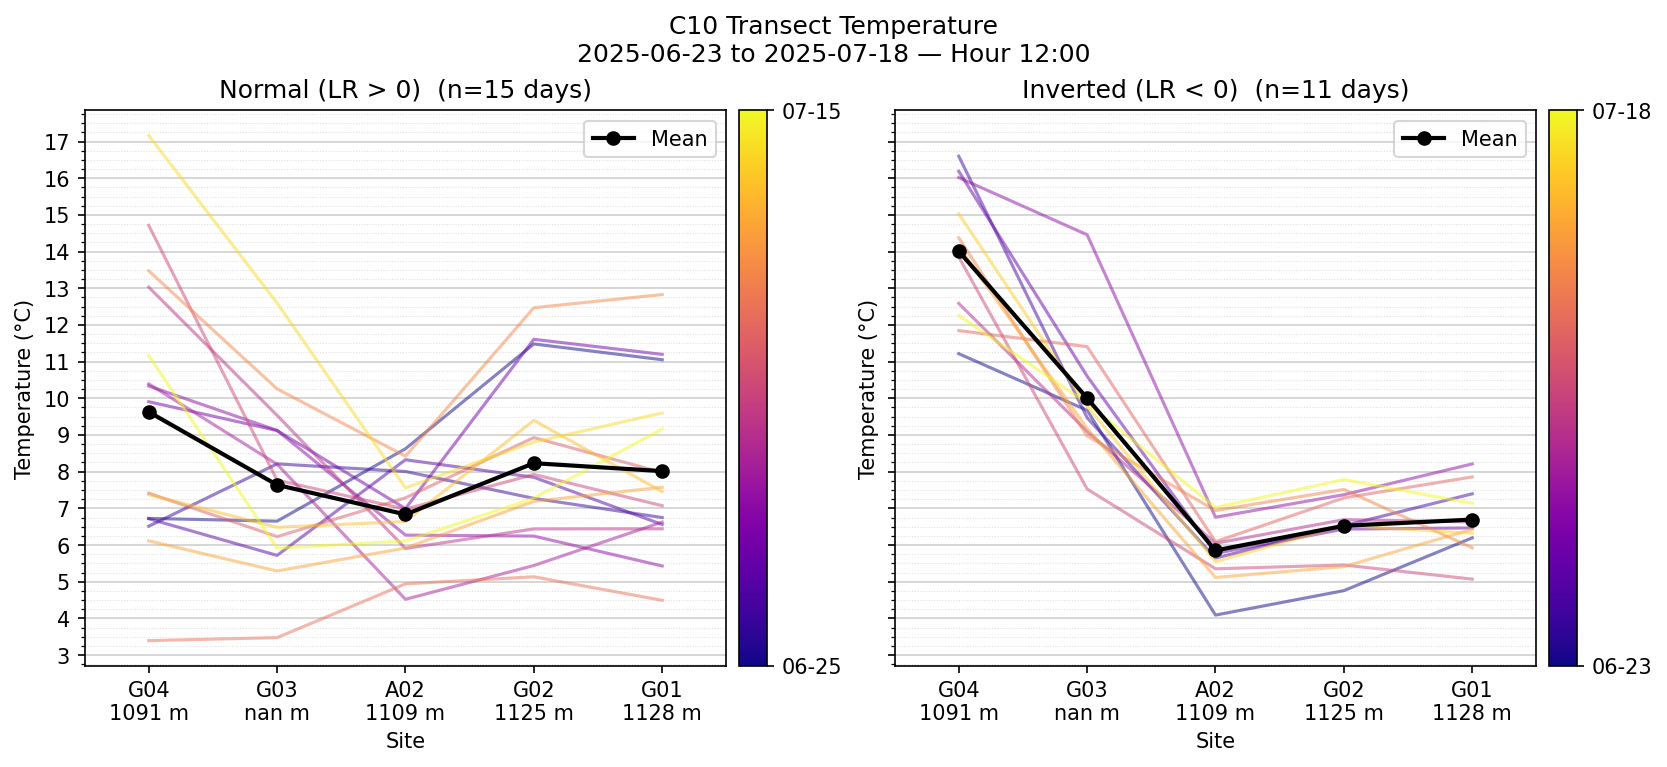

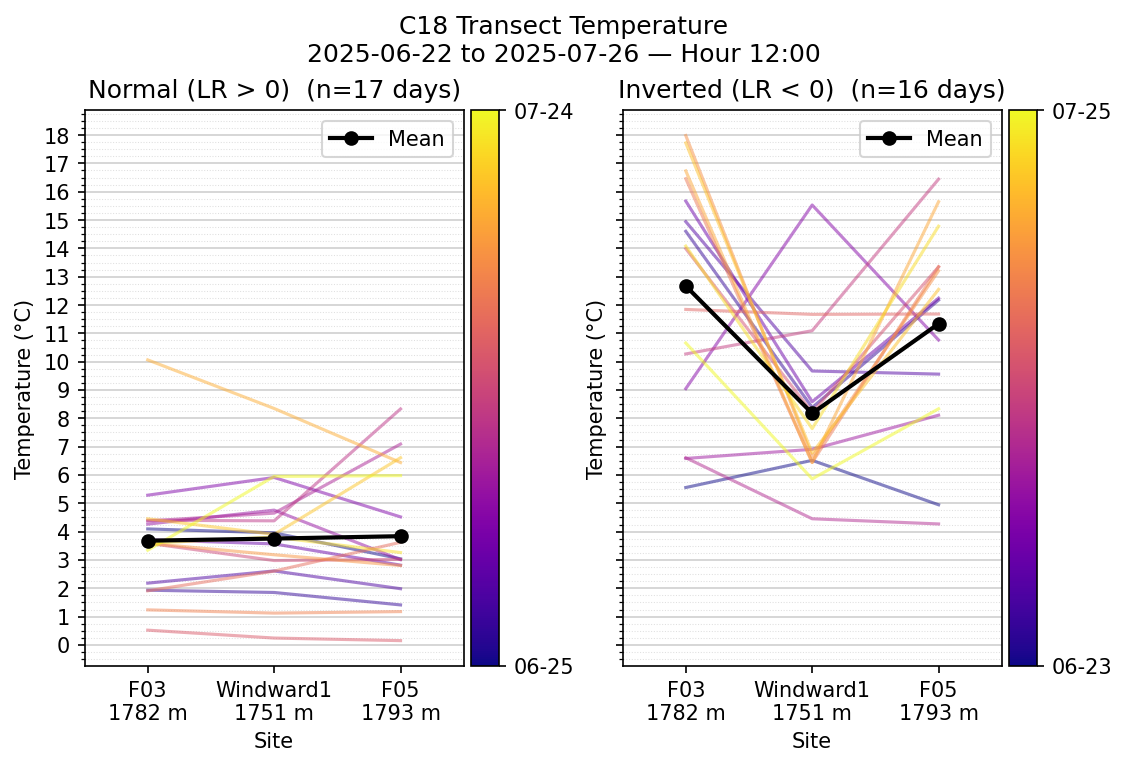

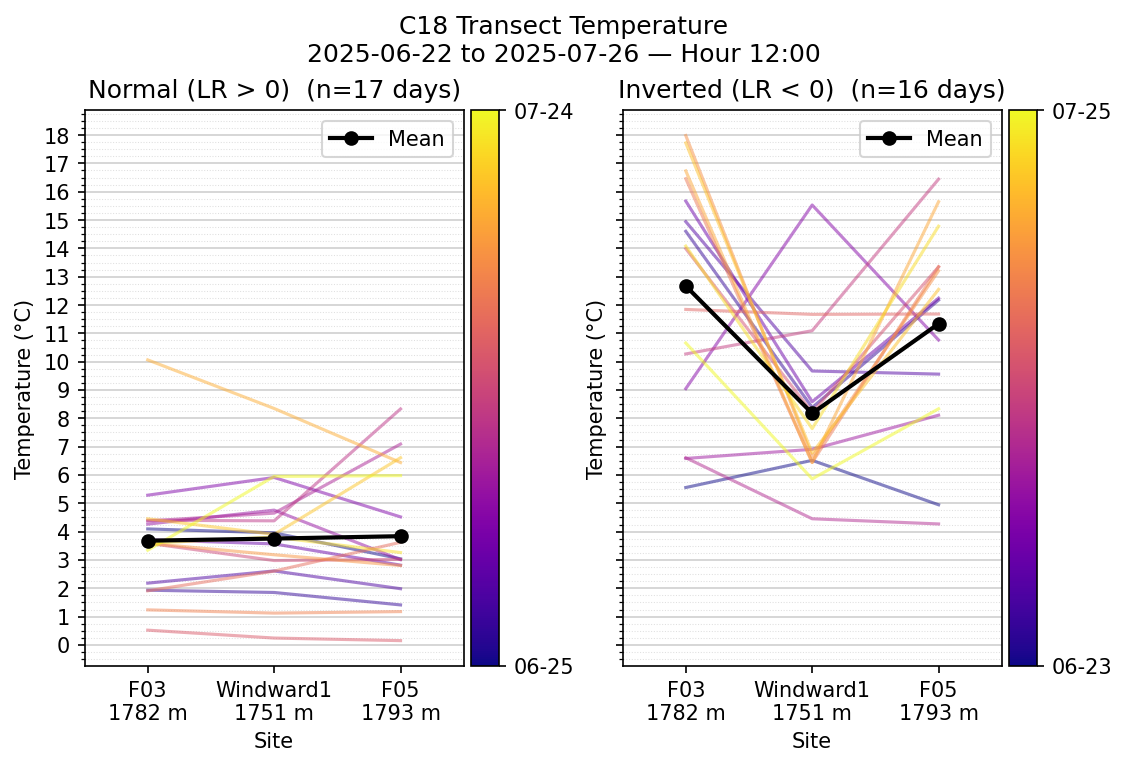

In [36]:
plot_transect_at_hour(
    C10_transect_1h,
    C10_SITES,
    title="C10 Transect Temperature",
    output_path=output_dir / "C10_transect_hour14.png",
    hour=12,
    lapse_rate=maritime_lapse_rate,
)

plot_transect_at_hour(
    C18_transect_1h,
    C18_SITES,
    title="C18 Transect Temperature",
    output_path=output_dir / "C18_transect_hour14.png",
    hour=12,
    lapse_rate=maritime_lapse_rate,
)

In [37]:
def plot_cumulative_degree_days_by_hour(
    da_transect, sites, title, output_path, lapse_rate=None, exclude_hours=None
):
    """Plot cumulative degree days accumulated during each hour of day across the transect.

    If lapse_rate is provided, produces a 2-column figure split by LR sign.
    Degree days are computed per observation using the sample interval inferred from
    the data, so the result is robust to resampling at any consistent frequency.
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
    x_pos = np.arange(len(present_sites))

    site_elevations = {}
    for site in present_sites:
        match = da_transect.where(da_transect.site_id == site, drop=True)
        if "elevation" in match.coords and match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    temps = np.stack(
        [da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
         for site in present_sites],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    dt_days = (datetimes[1] - datetimes[0]).total_seconds() / 86400.0
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    date_start = datetimes.min().strftime("%Y-%m-%d")
    date_end = datetimes.max().strftime("%Y-%m-%d")

    xticklabels = [
        f"{s}\n{site_elevations[s]:.0f} m" if s in site_elevations else s
        for s in present_sites
    ]

    def build_hourly_dd(df_subset):
        dd = df_subset.clip(lower=0) * dt_days
        hourly = dd.groupby(df_subset.index.hour).sum()
        if exclude_hours:
            hourly = hourly.drop(index=[h for h in exclude_hours if h in hourly.index])
        return hourly

    def draw_panel(ax, hourly_dd, cond_label, n_pts):
        hours = hourly_dd.index.values
        n = len(hours)
        colors = plt.get_cmap("rainbow", n)(np.arange(n))
        cmap = mcolors.ListedColormap(colors)
        bounds = np.arange(-0.5, n + 0.5, 1)
        norm = mcolors.BoundaryNorm(bounds, ncolors=n)
        for i, hour in enumerate(hours):
            ax.plot(x_pos, hourly_dd.loc[hour].values, marker="o", color=colors[i], lw=1.5, alpha=0.85)
        ax.set_xlim(-0.5, len(present_sites) - 0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels)
        ax.set_xlabel("Site")
        ax.set_ylabel("Cumulative Degree Days (°C·day)")
        ax.set_title(f"{cond_label}  (n={n_pts} timesteps)")
        ax.yaxis.set_major_locator(mticker.AutoLocator())
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
        ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, ticks=np.arange(n), boundaries=bounds, spacing="uniform", pad=0.02)
        cbar.set_label("Hour of Day")
        cbar.set_ticklabels([str(h) for h in hours])

    if lapse_rate is not None:
        lr_aligned = lapse_rate.reindex(datetimes, method="nearest", tolerance=pd.Timedelta("30min"))
        conditions = [
            ("Normal (LR > 0)", lr_aligned.values > 0),
            ("Inverted (LR < 0)", lr_aligned.values < 0),
        ]
        fig, axes = plt.subplots(
            1, 2,
            figsize=(len(present_sites) * 1.2 + 2, 6),
            dpi=150,
            layout="constrained",
            sharey=True,
        )
        for ax, (cond_label, mask) in zip(axes, conditions):
            draw_panel(ax, build_hourly_dd(df[mask]), cond_label, int(mask.sum()))
        fig.suptitle(f"{title}\n{date_start} to {date_end}")
    else:
        hourly_dd = build_hourly_dd(df)
        fig, ax = plt.subplots(figsize=(len(present_sites) * 1.2 + 2, 6), dpi=150)
        draw_panel(ax, hourly_dd, "All periods", len(datetimes))
        fig.suptitle(f"{title}\n{date_start} to {date_end}")
        fig.tight_layout()

    fig.savefig(output_path)
    plt.show()
    return fig

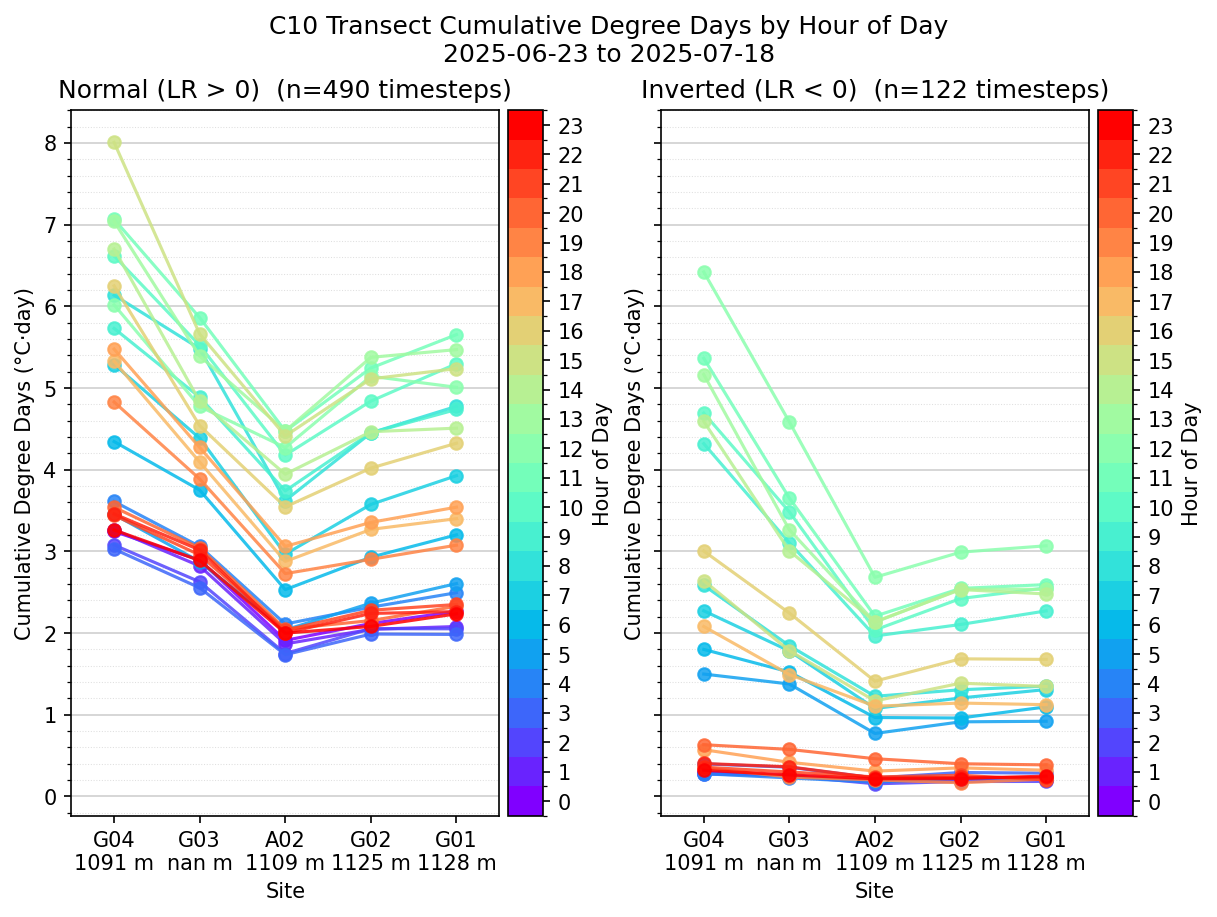

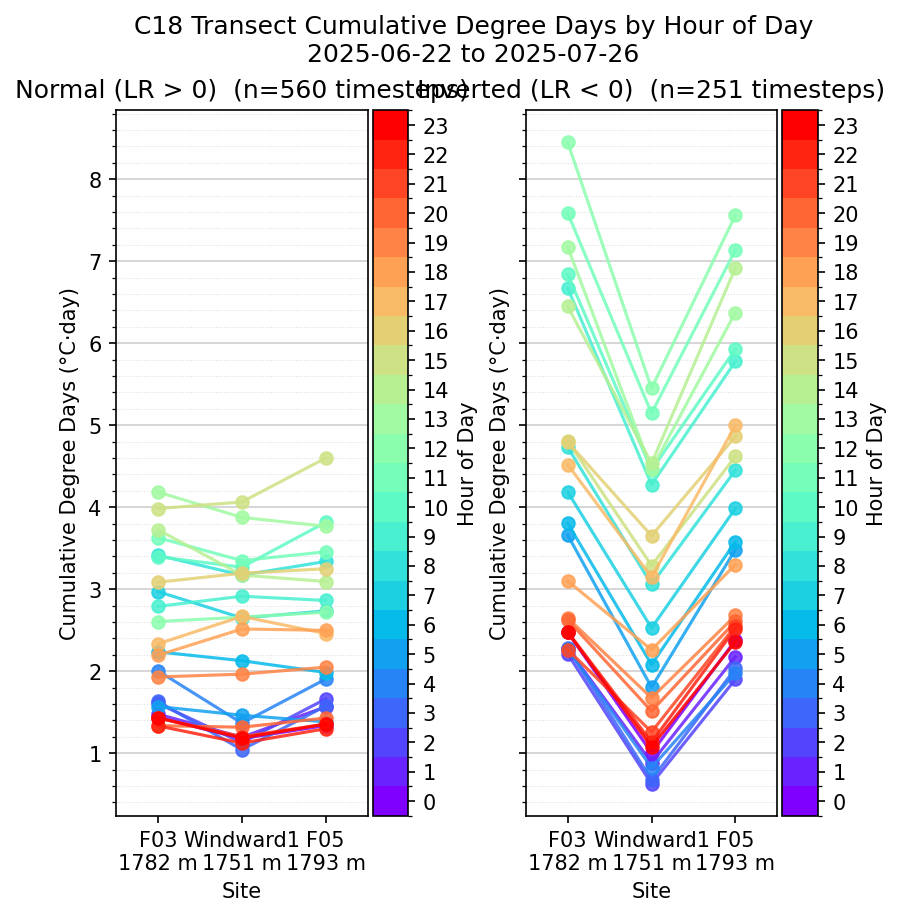

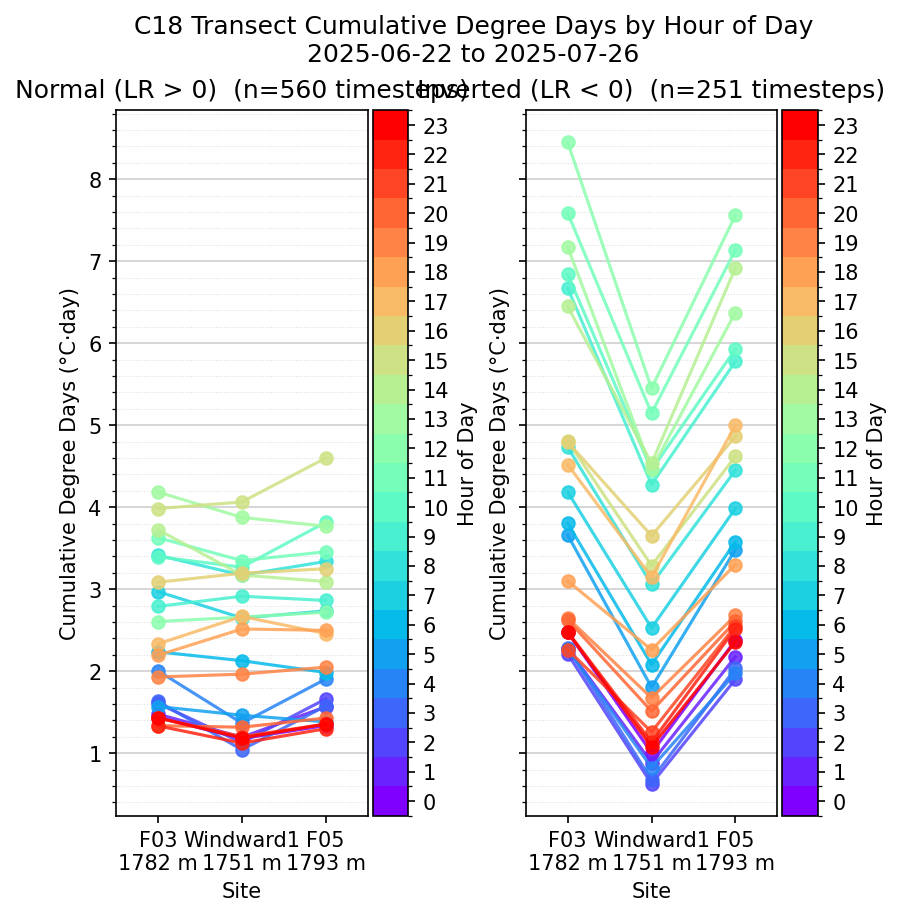

In [38]:
plot_cumulative_degree_days_by_hour(
    C10_transect_1h,
    C10_SITES,
    title="C10 Transect Cumulative Degree Days by Hour of Day",
    output_path=output_dir / "C10_transect_cumulative_dd_by_hour.png",
    lapse_rate=maritime_lapse_rate,
)

plot_cumulative_degree_days_by_hour(
    C18_transect_1h,
    C18_SITES,
    title="C18 Transect Cumulative Degree Days by Hour of Day",
    output_path=output_dir / "C18_transect_cumulative_dd_by_hour.png",
    lapse_rate=maritime_lapse_rate,
)